# 06 Supervised Target Definition

## Objective

This notebook defines and validates the supervised learning target for the next modeling step. The chosen target is `response`, which represents whether a customer accepted/responded to the most recent marketing campaign.

This step does not train supervised models, create a train/test split, scale variables, normalize variables, one-hot encode categorical fields, remove outliers, or create a different target. Model training happens in step 8.

## Setup

The reusable target-definition and modeling-data logic lives in `src/modeling_data.py`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from modeling_data import (
    CATEGORICAL_FEATURES,
    CLUSTERED_DATA_PATH,
    LEAKAGE_NOTES,
    MODELING_ASSUMPTIONS,
    MODELING_DATA_PATH,
    NUMERIC_FEATURES,
    TARGET_COLUMN,
    TARGET_SUMMARY_PATH,
    create_modeling_dataset,
    create_target_summary,
    get_excluded_features,
    load_clustered_data,
    save_modeling_data,
    save_target_summary,
    select_modeling_features,
    summarize_target,
    validate_modeling_dataset,
)

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 150)

print(f"Clustered data path: {CLUSTERED_DATA_PATH}")
print(f"Modeling data path: {MODELING_DATA_PATH}")
print(f"Target summary path: {TARGET_SUMMARY_PATH}")

Clustered data path: /Users/arjun/Documents/Intro DS final/data/processed/customer_clustered.csv
Modeling data path: /Users/arjun/Documents/Intro DS final/data/processed/modeling_data.csv
Target summary path: /Users/arjun/Documents/Intro DS final/reports/target_definition_summary.csv


## 1. Load and Inspect Data

The input is `data/processed/customer_clustered.csv`, which contains engineered features and the cluster labels from the unsupervised workflow.

In [2]:
df = load_clustered_data(CLUSTERED_DATA_PATH)
numeric_df = df.select_dtypes(include=[np.number])

print(f"Input shape: {df.shape}")
print(f"Missing values: {int(df.isna().sum().sum())}")
print(f"Infinite numeric values: {int(np.isinf(numeric_df.to_numpy()).sum())}")
print(f"Response column exists: {TARGET_COLUMN in df.columns}")
print(f"Cluster column exists: {'cluster' in df.columns}")

assert TARGET_COLUMN in df.columns
assert "cluster" in df.columns
assert df.isna().sum().sum() == 0
assert np.isinf(numeric_df.to_numpy()).sum() == 0

display(df.head())

Input shape: (2213, 54)
Missing values: 0
Infinite numeric values: 0
Response column exists: True
Cluster column exists: True


,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mnt_wines,mnt_fruits,mnt_meat_products,mnt_fish_products,mnt_sweet_products,mnt_gold_prods,num_deals_purchases,num_web_purchases,num_catalog_purchases,num_store_purchases,num_web_visits_month,accepted_cmp3,accepted_cmp4,accepted_cmp5,accepted_cmp1,accepted_cmp2,complain,z_cost_contact,z_revenue,response,age,customer_tenure_days,customer_tenure_years,children_total,has_children,household_size,total_spending,wine_share,fruits_share,meat_share,fish_share,sweets_share,gold_share,luxury_spending_ratio,spending_per_tenure_year,total_store_web_catalog_purchases,total_purchases,web_purchase_share,store_purchase_share,catalog_purchase_share,deal_purchase_share,average_spend_per_purchase,total_campaign_acceptances,any_campaign_acceptance,cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,57,663,1.815195,0,0,1,1617,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.447124,890.813348,22,25,0.363636,0.181818,0.454545,0.120000,73.500000,0,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,113,0.309377,2,1,3,27,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.629630,87.272124,4,6,0.250000,0.500000,0.250000,0.333333,6.750000,0,0,3
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,49,312,0.854209,0,0,2,776,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.603093,908.442308,20,21,0.400000,0.500000,0.100000,0.047619,38.800000,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,139,0.380561,1,1,3,53,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.301887,139.267986,6,8,0.333333,0.666667,0.000000,0.250000,8.833333,0,0,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,161,0.440794,1,1,3,422,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.445498,957.363354,14,19,0.357143,0.428571,0.214286,0.263158,30.142857,0,0,0


In [3]:
dtype_table = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "missing_values": df.isna().sum().to_numpy(),
})
display(dtype_table)

,column,dtype,missing_values
0,id,int64,0
1,year_birth,int64,0
2,education,str,0
3,marital_status,str,0
4,income,float64,0
5,kidhome,int64,0
6,teenhome,int64,0
7,dt_customer,datetime64[us],0
8,recency,int64,0
9,mnt_wines,int64,0


## 2. Define the Supervised Target

Target definition:

- `response = 1`: the customer accepted/responded to the most recent campaign.
- `response = 0`: the customer did not respond.

This is a reasonable target for supervised learning because it is binary, business-relevant, and already present in the Kaggle dataset.

In [4]:
target_summary = summarize_target(df[TARGET_COLUMN])
target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_pct = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

target_balance = pd.DataFrame({
    "class_count": target_counts,
    "class_pct": target_pct.round(2),
})
display(target_balance)

print(f"Positive class meaning: {target_summary['target_positive_class_meaning']}")
print(f"Baseline majority-class accuracy: {target_summary['baseline_majority_class_accuracy']:.4f}")

,class_count,class_pct
response,,
0,1880,84.95
1,333,15.05


Positive class meaning: Customer accepted/responded to the most recent marketing campaign
Baseline majority-class accuracy: 0.8495


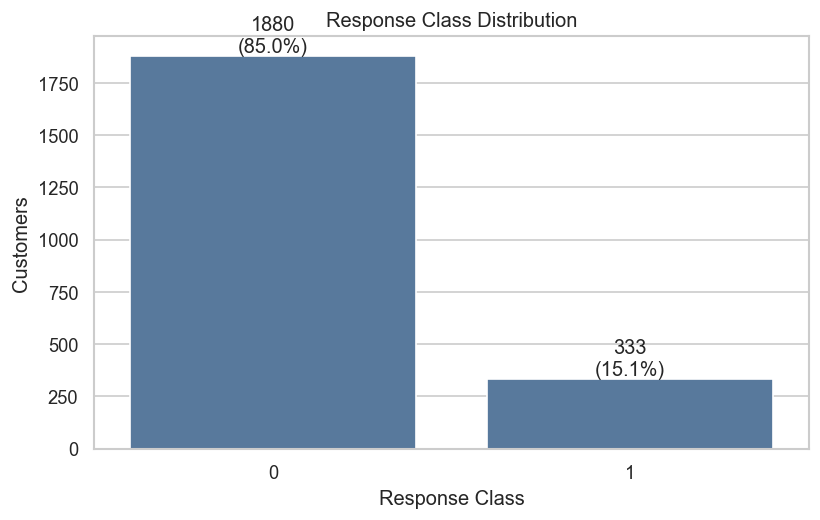

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=target_balance.index.astype(str), y=target_balance["class_count"], ax=ax, color="#4C78A8")
ax.set_title("Response Class Distribution")
ax.set_xlabel("Response Class")
ax.set_ylabel("Customers")
for index, value in enumerate(target_balance["class_count"]):
    ax.text(index, value, f"{value}\n({target_balance.iloc[index]['class_pct']:.1f}%)", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_response_distribution.png", bbox_inches="tight")
plt.show()

**Class imbalance note:** The positive response class is about 15% of the data. A model that always predicts the majority class would be about 85% accurate, so accuracy alone will not be a sufficient evaluation metric in step 8. Metrics such as precision, recall, F1, ROC-AUC, or PR-AUC should be considered later.

## 3. Leakage Review

The modeling dataset excludes direct identifiers, the target itself, and raw date fields. It also excludes raw columns when engineered versions are more useful or less redundant.

Historical campaign features require a modeling assumption. In this project, `total_campaign_acceptances` and `any_campaign_acceptance` are allowed because they summarize prior campaign behavior and the target is response to the most recent campaign. The individual `accepted_cmp1` through `accepted_cmp5` fields are excluded to keep the feature set compact and avoid relying too heavily on specific campaign flags.

In [6]:
selected_features = select_modeling_features()
excluded_features = get_excluded_features()

print("Leakage notes:")
print(LEAKAGE_NOTES)
print("\nModeling assumptions:")
print(MODELING_ASSUMPTIONS)

print("\nExcluded features:")
for feature in excluded_features:
    print(f"- {feature}")

direct_leakage_overlap = sorted(set(["id", TARGET_COLUMN, "dt_customer"]).intersection(selected_features))
print(f"\nDirect leakage columns accidentally selected: {direct_leakage_overlap}")
assert direct_leakage_overlap == []

Leakage notes:
Excluded id, response, and raw dt_customer. Response is the target and is not used as a feature. Raw dates are excluded in favor of tenure features. Individual accepted_cmp1 through accepted_cmp5 columns are excluded to keep the feature set compact and avoid overly campaign-specific indicators.

Modeling assumptions:
The target predicts response to the most recent campaign. Summarized historical campaign behavior, total_campaign_acceptances and any_campaign_acceptance, is allowed because it represents prior campaign history rather than the current response outcome.

Excluded features:
- id
- response
- dt_customer
- year_birth
- kidhome
- teenhome
- mnt_wines
- mnt_fruits
- mnt_meat_products
- mnt_fish_products
- mnt_sweet_products
- mnt_gold_prods
- num_deals_purchases
- num_web_purchases
- num_catalog_purchases
- num_store_purchases
- z_cost_contact
- z_revenue
- accepted_cmp1
- accepted_cmp2
- accepted_cmp3
- accepted_cmp4
- accepted_cmp5

Direct leakage columns accid

## 4. Feature Set Planning

The planned modeling dataset keeps categorical variables as readable columns for now. Encoding, train/test split, scaling, and model-specific preprocessing will happen in step 8.

In [7]:
feature_plan = pd.DataFrame({
    "feature": selected_features,
    "feature_type": [
        "categorical" if feature in CATEGORICAL_FEATURES else "numeric"
        for feature in selected_features
    ],
})

print(f"Selected feature count: {len(selected_features)}")
print(f"Categorical feature count: {len(CATEGORICAL_FEATURES)}")
print(f"Numeric feature count: {len(NUMERIC_FEATURES)}")
display(feature_plan)

Selected feature count: 31
Categorical feature count: 3
Numeric feature count: 28


,feature,feature_type
0,education,categorical
1,marital_status,categorical
2,cluster,categorical
3,age,numeric
4,income,numeric
5,children_total,numeric
6,has_children,numeric
7,household_size,numeric
8,customer_tenure_days,numeric
9,customer_tenure_years,numeric


## 5. Create Modeling Dataset

The modeling dataset includes the selected features plus the target column `response`. It intentionally does not one-hot encode, scale, normalize, split, or train models.

In [8]:
modeling_df = create_modeling_dataset(df)
validation = validate_modeling_dataset(modeling_df)

display(pd.Series(validation, name="count").to_frame())
display(modeling_df.head())

save_modeling_data(modeling_df, MODELING_DATA_PATH)
print(f"Saved modeling data to: {MODELING_DATA_PATH}")

assert modeling_df.isna().sum().sum() == 0
assert np.isinf(modeling_df.select_dtypes(include=[np.number]).to_numpy()).sum() == 0
assert TARGET_COLUMN in modeling_df.columns

,count
rows,2213
columns,32
missing_values,0
infinite_values,0
feature_count,31
categorical_feature_count,3
numeric_feature_count,28


,education,marital_status,cluster,age,income,children_total,has_children,household_size,customer_tenure_days,customer_tenure_years,recency,complain,total_spending,wine_share,fruits_share,meat_share,fish_share,sweets_share,gold_share,luxury_spending_ratio,spending_per_tenure_year,total_purchases,total_store_web_catalog_purchases,web_purchase_share,store_purchase_share,catalog_purchase_share,deal_purchase_share,average_spend_per_purchase,num_web_visits_month,total_campaign_acceptances,any_campaign_acceptance,response
0,Graduation,Single,0,57,58138.0,0,0,1,663,1.815195,58,0,1617,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.447124,890.813348,25,22,0.363636,0.181818,0.454545,0.120000,73.500000,7,0,0,1
1,Graduation,Single,3,60,46344.0,2,1,3,113,0.309377,38,0,27,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.629630,87.272124,6,4,0.250000,0.500000,0.250000,0.333333,6.750000,5,0,0,0
2,Graduation,Together,0,49,71613.0,0,0,2,312,0.854209,26,0,776,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.603093,908.442308,21,20,0.400000,0.500000,0.100000,0.047619,38.800000,4,0,0,0
3,Graduation,Together,1,30,26646.0,1,1,3,139,0.380561,26,0,53,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.301887,139.267986,8,6,0.333333,0.666667,0.000000,0.250000,8.833333,6,0,0,0
4,PhD,Married,0,33,58293.0,1,1,3,161,0.440794,94,0,422,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.445498,957.363354,19,14,0.357143,0.428571,0.214286,0.263158,30.142857,5,0,0,0


Saved modeling data to: /Users/arjun/Documents/Intro DS final/data/processed/modeling_data.csv


## 6. Target Analysis

The following tables and plots examine how response rates differ across clusters, demographics, campaign history, and simple income/spending bands. These are descriptive checks only, not model results.

In [9]:
def response_rate_table(data, group_col):
    table = data.groupby(group_col)[TARGET_COLUMN].agg(["mean", "count"]).rename(columns={"mean": "response_rate"})
    table["response_rate_pct"] = table["response_rate"] * 100
    return table.sort_values("response_rate", ascending=False)

print("Response rate by cluster")
response_by_cluster = response_rate_table(df, "cluster")
display(response_by_cluster)

print("Response rate by education")
response_by_education = response_rate_table(df, "education")
display(response_by_education)

print("Response rate by marital status")
response_by_marital = response_rate_table(df, "marital_status")
display(response_by_marital)

print("Response rate by has_children")
response_by_children = response_rate_table(df, "has_children")
display(response_by_children)

print("Response rate by campaign history")
response_by_campaign_history = response_rate_table(df, "any_campaign_acceptance")
display(response_by_campaign_history)

Response rate by cluster


,response_rate,count,response_rate_pct
cluster,,,
0,0.250375,667,25.037481
2,0.134375,640,13.437500
1,0.101695,413,10.169492
3,0.077079,493,7.707911


Response rate by education


,response_rate,count,response_rate_pct
education,,,
PhD,0.210417,480,21.041667
Master,0.153425,365,15.342466
Graduation,0.136201,1116,13.620072
2n Cycle,0.111111,198,11.111111
Basic,0.037037,54,3.703704


Response rate by marital status


,response_rate,count,response_rate_pct
marital_status,,,
Absurd,0.500000,2,50.000000
YOLO,0.500000,2,50.000000
Alone,0.333333,3,33.333333
Widow,0.236842,76,23.684211
Single,0.225532,470,22.553191
Divorced,0.207792,231,20.779221
Married,0.114352,857,11.435239
Together,0.104895,572,10.489510


Response rate by has_children


,response_rate,count,response_rate_pct
has_children,,,
0,0.265823,632,26.582278
1,0.104364,1581,10.436433


Response rate by campaign history


,response_rate,count,response_rate_pct
any_campaign_acceptance,,,
1,0.408297,458,40.829694
0,0.083191,1755,8.319088


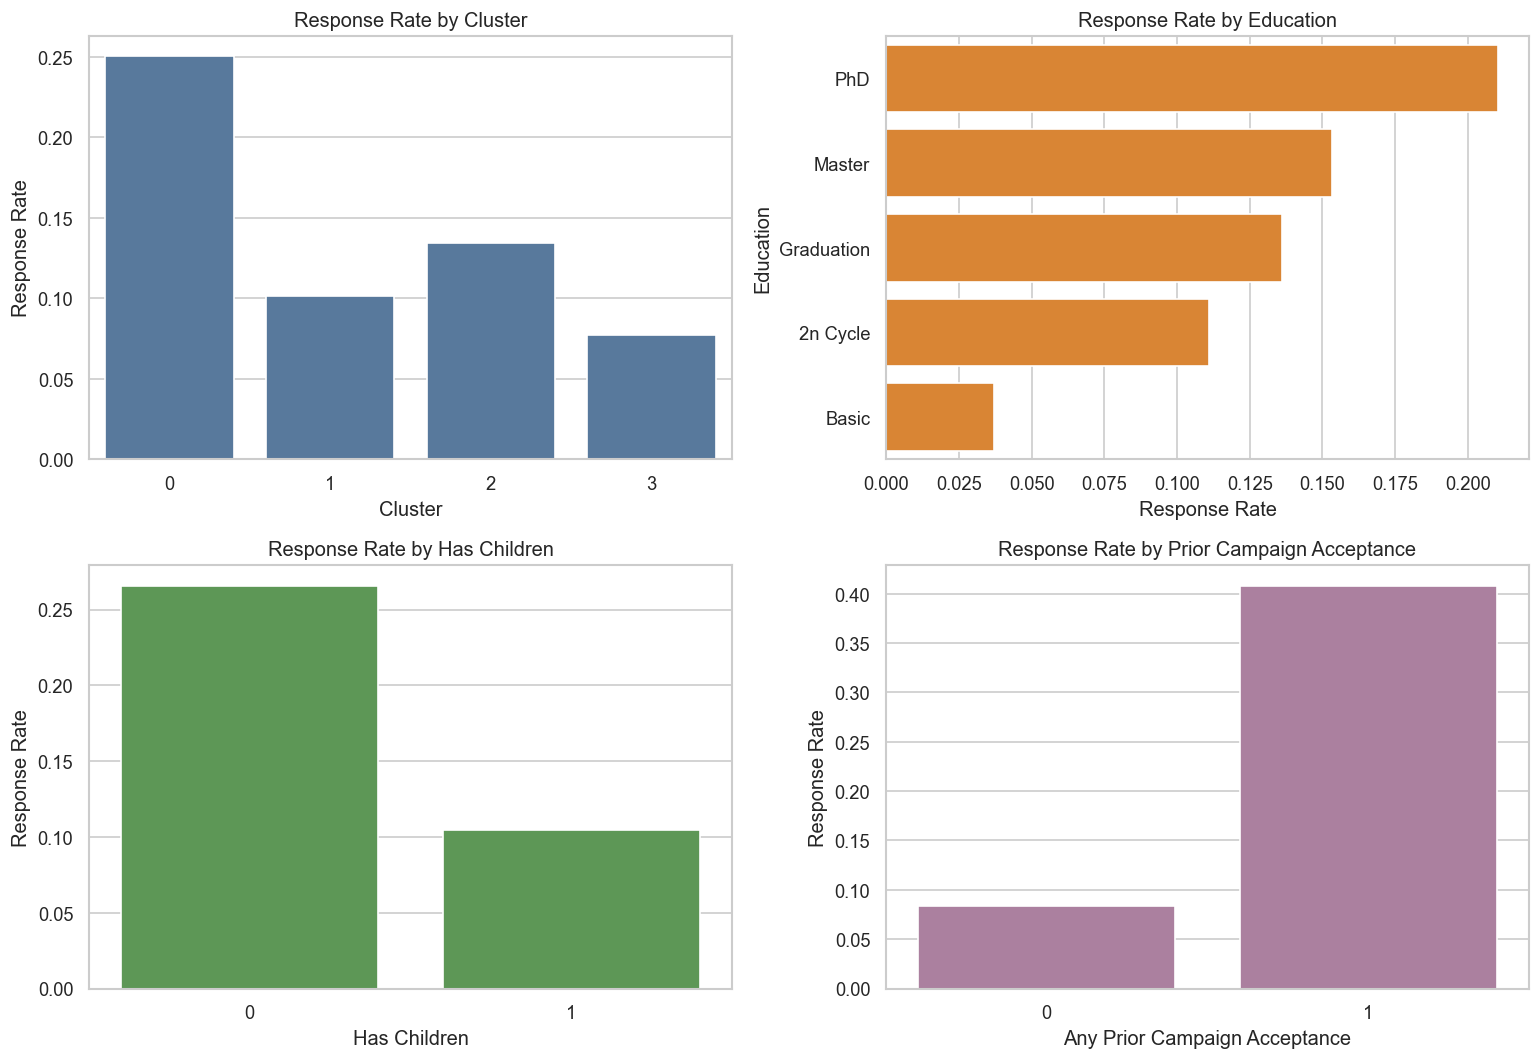

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.barplot(data=response_by_cluster.reset_index(), x="cluster", y="response_rate", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Response Rate by Cluster")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Response Rate")

education_plot = response_by_education.reset_index()
sns.barplot(data=education_plot, y="education", x="response_rate", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Response Rate by Education")
axes[0, 1].set_xlabel("Response Rate")
axes[0, 1].set_ylabel("Education")

sns.barplot(data=response_by_children.reset_index(), x="has_children", y="response_rate", ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Response Rate by Has Children")
axes[1, 0].set_xlabel("Has Children")
axes[1, 0].set_ylabel("Response Rate")

sns.barplot(data=response_by_campaign_history.reset_index(), x="any_campaign_acceptance", y="response_rate", ax=axes[1, 1], color="#B279A2")
axes[1, 1].set_title("Response Rate by Prior Campaign Acceptance")
axes[1, 1].set_xlabel("Any Prior Campaign Acceptance")
axes[1, 1].set_ylabel("Response Rate")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_response_rates_by_groups.png", bbox_inches="tight")
plt.show()

In [11]:
banded_df = df.copy()
banded_df["income_band"] = pd.qcut(banded_df["income"], q=4, duplicates="drop")
banded_df["spending_band"] = pd.qcut(banded_df["total_spending"], q=4, duplicates="drop")

response_by_income_band = response_rate_table(banded_df, "income_band")
response_by_spending_band = response_rate_table(banded_df, "spending_band")

print("Response rate by income quartile")
display(response_by_income_band)

print("Response rate by total spending quartile")
display(response_by_spending_band)

Response rate by income quartile


,response_rate,count,response_rate_pct
income_band,,,
"(68487.0, 666666.0]",0.269439,553,26.943942
"(35246.0, 51373.0]",0.124774,553,12.477396
"(1729.999, 35246.0]",0.104693,554,10.469314
"(51373.0, 68487.0]",0.103074,553,10.307414


Response rate by total spending quartile


,response_rate,count,response_rate_pct
spending_band,,,
"(1048.0, 2525.0]",0.302536,552,30.253623
"(69.0, 397.0]",0.120219,549,12.021858
"(397.0, 1048.0]",0.119565,552,11.956522
"(4.999, 69.0]",0.060714,560,6.071429


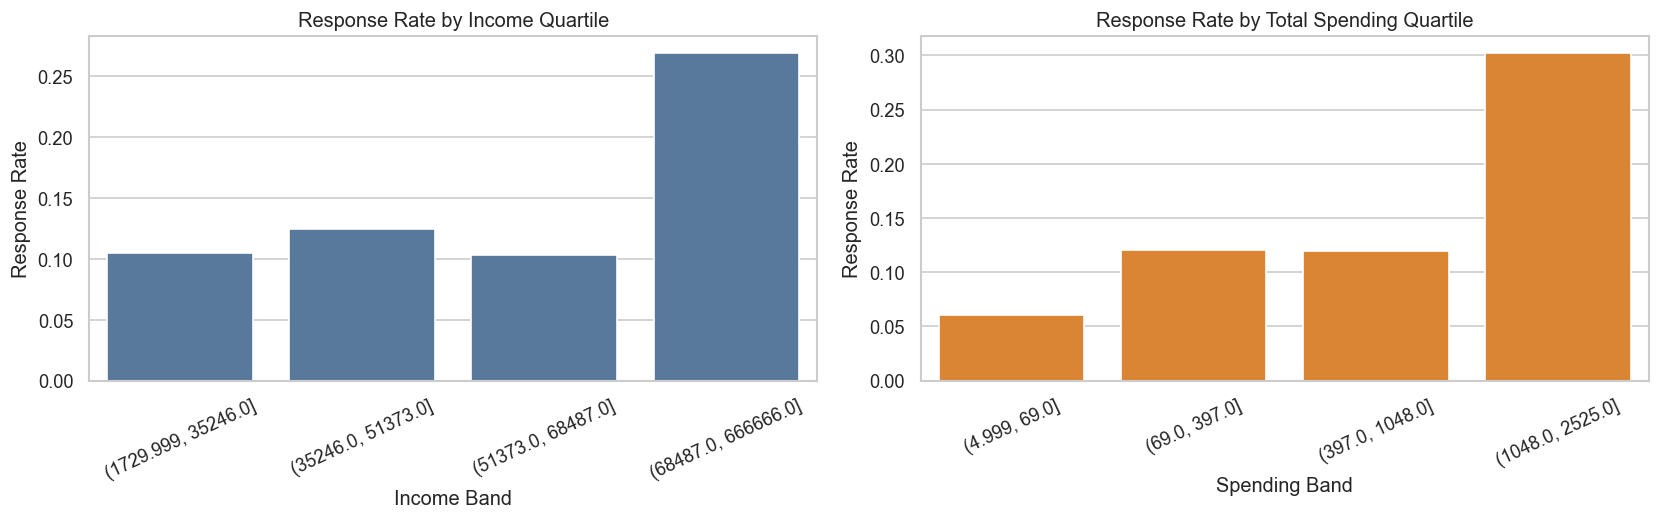

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

income_plot = response_by_income_band.reset_index().sort_values("income_band")
income_plot["income_band"] = income_plot["income_band"].astype(str)
sns.barplot(data=income_plot, x="income_band", y="response_rate", ax=axes[0], color="#4C78A8")
axes[0].set_title("Response Rate by Income Quartile")
axes[0].set_xlabel("Income Band")
axes[0].set_ylabel("Response Rate")
axes[0].tick_params(axis="x", rotation=25)

spending_plot = response_by_spending_band.reset_index().sort_values("spending_band")
spending_plot["spending_band"] = spending_plot["spending_band"].astype(str)
sns.barplot(data=spending_plot, x="spending_band", y="response_rate", ax=axes[1], color="#F58518")
axes[1].set_title("Response Rate by Total Spending Quartile")
axes[1].set_xlabel("Spending Band")
axes[1].set_ylabel("Response Rate")
axes[1].tick_params(axis="x", rotation=25)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_response_rates_by_bands.png", bbox_inches="tight")
plt.show()

## 7. Save Target Definition Summary

The summary file captures target balance, baseline accuracy, feature counts, leakage notes, and the historical campaign assumption.

In [13]:
summary_df = create_target_summary(modeling_df)
save_target_summary(summary_df, TARGET_SUMMARY_PATH)

display(summary_df)
print(f"Saved target definition summary to: {TARGET_SUMMARY_PATH}")

,target_name,target_positive_class_meaning,total_rows,positive_count,negative_count,positive_rate,negative_rate,baseline_majority_class_accuracy,selected_feature_count,categorical_feature_count,numeric_feature_count,leakage_notes,modeling_assumptions
0,response,Customer accepted/responded to the most recent...,2213,333,1880,0.150474,0.849526,0.849526,31,3,28,"Excluded id, response, and raw dt_customer. Re...",The target predicts response to the most recen...


Saved target definition summary to: /Users/arjun/Documents/Intro DS final/reports/target_definition_summary.csv


## 8. Validation and Next Step

The modeling dataset is ready for step 8, where preprocessing, train/test splitting, supervised model training, and evaluation will be handled.

In [14]:
saved_modeling_df = pd.read_csv(MODELING_DATA_PATH)
saved_summary_df = pd.read_csv(TARGET_SUMMARY_PATH)
saved_figures = sorted(path.name for path in FIGURE_DIR.glob("target_*.png"))

print(f"Saved modeling data shape: {saved_modeling_df.shape}")
print(f"Saved summary shape: {saved_summary_df.shape}")
print(f"Saved modeling missing values: {int(saved_modeling_df.isna().sum().sum())}")
print(f"Saved modeling infinite values: {int(np.isinf(saved_modeling_df.select_dtypes(include=[np.number]).to_numpy()).sum())}")
print("Saved target figures:")
for figure in saved_figures:
    print(f"- {figure}")

assert saved_modeling_df.shape == modeling_df.shape
assert saved_summary_df.shape[0] == 1
assert saved_modeling_df.isna().sum().sum() == 0
assert np.isinf(saved_modeling_df.select_dtypes(include=[np.number]).to_numpy()).sum() == 0

Saved modeling data shape: (2213, 32)
Saved summary shape: (1, 13)
Saved modeling missing values: 0
Saved modeling infinite values: 0
Saved target figures:
- target_response_distribution.png
- target_response_rates_by_bands.png
- target_response_rates_by_groups.png
